# <center> Лабораторная 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re

### Task 1. 

Для заданного ниже объекта s проделайте следующее:
1. Создайте новый Series, значения которого совпадают со значениями s, а индексы - целочисленные значения от 5 до 20, не включая 20. 
2. Выберите из нового s только целочисленные элементы и вычислите их дисперсию. (\*)

Все полученные результаты округлите до 2-х знаков после запятой.


##### Пояснения:
(\*) Целочисленные значения - значения, имеющие тип int.
- Дисперсия рассчитывается с помощью функции из библиотеки numpy: np.var( , ddof=0) или встроенной в python функции: .var(ddof=1)

In [3]:
s = pd.Series(data=['13', 2, 77.1, 'red', 8, -341, 12.42, '34', 19.02, 72, 1, 87, 12.03, 'green', 0.05], 
              index=range(6, 36, 2))
s2 = pd.Series(s.values,
              index=range(5, 20))
print(s2)
print()
s2 = s2[s2.apply(lambda x: isinstance(x, int))]
d = np.var(s2, ddof=0).round(2)
print(s2, "\n")
print(d)

5        13
6         2
7      77.1
8       red
9         8
10     -341
11    12.42
12       34
13    19.02
14       72
15        1
16       87
17    12.03
18    green
19     0.05
dtype: object

6        2
9        8
10    -341
14      72
15       1
16      87
dtype: object 

20704.92


### Task 2. 
1. Сгенерируйте Series из 100 значений нормально распределённой СВ (np.random.normal с дефолтными параметрами - нулевым средним и единичной дисперсией).
2. Возведите каждое значение серии в 3 степень, а значения индекса увеличьте в 3 раза. 
3. Ответьте на следующие вопросы через запятую (без пробелов) (\*)
    - 1) Выведите сумму элементов, строго меньших 2.6, имеющих чётные значения индекса. 
    - 2) Выведите количество значений серии больше нуля.

#### Пояснения:
 - Определенное значение seed нужно, чтобы ответы у всех выполняющих
это задание были одинаковые и их можно было проверить (так как генерируются
одинаковые series).
 - Следует внимательнее использовать [ ] для выбора данных по нескольким условиям:
либо выбирать данные последовательно, либо сразу по нескольким условиям,
но через оператор &. Отличие оператора and от оператора &: and - выводит
последнее проверенное значение, & - выводит пересечение значений.
Пример: s[ _  &  _ ].sum() 

In [4]:
np.random.seed(242)
s = pd.Series(np.random.normal(size=100))
print(s)
s = pd.Series((s**3).values, index = s.index * 3)
print("\n", s)
summa = s[(s < 2.6) & (s.index % 2 == 0)].sum()
count =  (s > 0).sum()
print()
print(summa, count, sep=',')

0    -0.357519
1     0.148448
2     0.993531
3     1.838968
4    -0.744026
        ...   
95    0.950296
96    0.737315
97   -0.739985
98   -1.376260
99    0.052260
Length: 100, dtype: float64

 0     -0.045698
3      0.003271
6      0.980718
9      6.219024
12    -0.411874
         ...   
285    0.858176
288    0.400829
291   -0.405199
294   -2.606764
297    0.000143
Length: 100, dtype: float64

-19.455490619511657,49


#### Структура популярного датасета **«Титаник»** выглядит следующим образом:

| Колонка         | Тип данных | Описание                                     |
|-----------------|------------|----------------------------------------------|
| PassengerId     | integer    | Уникальный номер пассажира                   |
| Survived        | integer    | Показатель выживания (0 — погиб, 1 — выжил) |
| Pclass          | integer    | Класс билета (1-й, 2-й, 3-й классы)         |
| Name            | object     | Имя пассажира                                |
| Sex             | object     | Пол пассажира («male» или «female»)         |
| Age             | float      | Возраст пассажира                            |
| SibSp           | integer    | Количество братьев/сестер/супругов на борту |
| Parch           | integer    | Количество родителей/детей на борту         |
| Ticket          | object     | Номер билета                                 |
| Fare            | float      | Стоимость проезда                           |
| Cabin           | object     | Номер каюты (частично отсутствуют данные)   |
| Embarked        | object     | Порт посадки («C», «Q», «S»)                 |



### Task 3.
Используя датасет Titanic, провести Exploratory Data Analysis (EDA) (с помощью описательной статистики), выявить основные факторы, повлиявшие на выживаемость пассажиров, рассчитать долю спасённых мужчин и женщин.

In [8]:
df = pd.read_csv('titanic.csv')

def age_category(age):
    if age < 18:
        return "дети"
    elif age < 60:
        return "взрослые"
    return "пенсионеры"

df['Возрастная_категория'] = df['Age'].apply(age_category)
survival_by_age = df.groupby('Возрастная_категория')['Survived'].agg(['count', 'sum'])
survival_by_age['Доля_выживших'] = survival_by_age['sum'] / survival_by_age['count'] * 100
print(survival_by_age['Доля_выживших'], "\n")

df = df.rename(columns={'Pclass': 'Класс_билета', 'Sex': 'Пол'})
survival_by_pclass = df.groupby('Класс_билета')['Survived'].agg(['count', 'sum'])
survival_by_pclass['Доля_выживших'] = survival_by_pclass['sum'] / survival_by_pclass['count'] * 100
print(survival_by_pclass['Доля_выживших'], "\n")

survival_by_sex = df.groupby('Пол')['Survived'].agg(['count', 'sum'])
survival_by_sex['Доля_выживших'] = survival_by_sex['sum'] / survival_by_sex['count'] * 100
print(survival_by_sex['Доля_выживших'])

Возрастная_категория
взрослые      38.608696
дети          53.982301
пенсионеры    29.064039
Name: Доля_выживших, dtype: float64 

Класс_билета
1    62.962963
2    47.282609
3    24.236253
Name: Доля_выживших, dtype: float64 

Пол
female    74.203822
male      18.890815
Name: Доля_выживших, dtype: float64



#### Вот таблица, отображающая структуру датасета bank_data.csv:

| Column Name    | Type                 | Description                             |
|----------------|----------------------|-----------------------------------------|
| Client_ID      | int                  | Идентификатор клиента                   |
| Date           | string               | Дата рождения клиента (формат: YYYY-MM-DD) |
| Profession     | category/string      | Профессиональная деятельность клиента   |
| Income         | float                | Годовой доход клиента                    |
| Loan_Balance   | float                | Текущий остаток по кредиту               |
| Gender         | category/string      | Пол клиента ("Male"/"Female")           |


### Task 4.
Загрузите данные из файла 'bank_data.csv'. Проверьте структуру загруженных данных: выведите первые 5 записей и размеры таблицы (строки x столбцы).Посчитайте общее число клиентов банка и количество уникальных профессий среди клиентов.
Проверить наличие пропусков в данных и заполнить пустые значения средней величиной соответствующего столбца.


In [17]:
df_bank = pd.read_csv('bank_data.csv')

In [14]:
print(df_bank.head(5))
print(df_bank.shape)
print(f'общее число клиентов банка: {len(df_bank)}')
print(f'количество уникальных профессий: {df_bank['Profession'].nunique()}')

na_per_column = df_bank.isna().sum()
print("\nколичество пропусков в каждом столбце\n", na_per_column)

df_bank['Income'] = df_bank['Income'].fillna(df_bank.Income.mean())
print(df_bank.head(5))

   Client_ID        Date Profession        Income  Loan_Balance  Gender
0          1  1960-01-01     Doctor  51640.921919  11493.764542    Male
1          2  1960-01-15   Engineer           NaN   6241.044750  Female
2          3  1960-01-30   Designer           NaN   7868.212019    Male
3          4  1960-02-14   Engineer  53358.260364  15742.228546  Female
4          5  1960-02-29   Engineer  38142.883168  10566.352053  Female
(1000, 6)
общее число клиентов банка: 1000
количество уникальных профессий: 5

количество пропусков в каждом столбце
 Client_ID        0
Date             0
Profession       0
Income          50
Loan_Balance     0
Gender           0
dtype: int64
   Client_ID        Date Profession        Income  Loan_Balance  Gender
0          1  1960-01-01     Doctor  51640.921919  11493.764542    Male
1          2  1960-01-15   Engineer  51144.823989   6241.044750  Female
2          3  1960-01-30   Designer  51144.823989   7868.212019    Male
3          4  1960-02-14   Engineer

### Task 5.
Преобразуйте строку 'Date' в тип datetime и извлеките из нее год, месяц и день рождения клиентов отдельно в новые столбцы.
Отфильтруйте записи клиентов старше 30 лет и подсчитайте средний доход для этой выборки.
Проведите группировку клиентов по профессиям и вычислите среднюю сумму кредита для каждой профессии.
Для всех кредитных сумм выполните стандартизацию (приведение к нормальному распределению).
Удалите ненужные столбцы и преобразуйте категорию профессии в числовой вид (one-hot encoding).
Сохраните обработанные данные в новый CSV-файл для дальнейшего использования в обучении нейронных сетей.

In [18]:
df_bank['Date'] = pd.to_datetime(df_bank['Date'])
df_bank['Year'] = df_bank['Date'].dt.year
df_bank['Month'] = df_bank['Date'].dt.month
df_bank['Day'] = df_bank['Date'].dt.day

df_older30 = df_bank[(df_bank['Year'] <= 1996) & (df_bank['Month'] <= 3) & (df_bank['Day'] <= 25)]
print(f'средний доход клиентов старше 30 лет: {df_older30.Income.mean()}\n')

df_by_profession = df_bank.groupby('Profession')['Loan_Balance'].agg(['count', 'sum'])
df_by_profession['средняя сумма кредита'] = df_by_profession['sum'] / df_by_profession['count']
print(df_by_profession, "\n")

df_bank['Loan_Balance_norm'] = (df_bank['Loan_Balance'] - df_bank['Loan_Balance'].min()) / (df_bank['Loan_Balance'].max() - df_bank['Loan_Balance'].min())

df_bank.pop('Date')
df_bank.pop('Loan_Balance')
df_bank = pd.get_dummies(df_bank, columns=['Profession'])
print(df_bank)
df_bank.to_csv('bank_data_new.csv')

средний доход клиентов старше 30 лет: 51835.937695873334

            count           sum  средняя сумма кредита
Profession                                            
Designer      190  1.884594e+06            9918.913324
Developer     190  1.899046e+06            9994.977918
Doctor        206  2.165593e+06           10512.587489
Engineer      204  2.062876e+06           10112.137794
Manager       210  2.082551e+06            9916.911214 

     Client_ID        Income  Gender  Year  Month  Day  Loan_Balance_norm  \
0            1  51640.921919    Male  1960      1    1           0.538919   
1            2           NaN  Female  1960      1   15           0.368300   
2            3           NaN    Male  1960      1   30           0.421154   
3            4  53358.260364  Female  1960      2   14           0.676918   
4            5  38142.883168  Female  1960      2   29           0.508795   
..         ...           ...     ...   ...    ...  ...                ...   
995        996  

#### Информация для последующих заданий
- Для всех последующих заданий будем использовать обезличенные транзакционные банковские данные. Для этого считайте в переменные tr_mcc_codes, tr_types, transactions и gender_train из одноимённых таблиц из папки data. Для таблицы transactions используйте только первые n=1000000 строк. Обратите внимание на разделители внутри каждого из файлов - они могут различаться!

In [30]:
tr_mcc_codes = pd.read_csv('tr_mcc_codes.csv', sep=';')
tr_types = pd.read_csv("tr_types.csv", sep=';')
transactions = pd.read_csv("transactions.csv", sep=',', nrows = 1000000)
gender_train = pd.read_csv("gender_train.csv", sep=',')

#### Описание данных
#### Таблица ```transactions.csv```
##### Описание
Таблица содержит историю транзакций клиентов банка за один год и три месяца.

##### Формат данных

```
customer_id,tr_datetime,mcc_code,tr_type,amount,term_id
111111,15 01:40:52,1111,1000,-5224,111111
111112,15 15:18:32,3333,2000,-100,11122233
...
```
##### Описание полей

 - ```customer_id``` — идентификатор клиента;
 - ```tr_datetime``` — день и время совершения транзакции (дни нумеруются с начала данных);
 - ```mcc_code``` — mcc-код транзакции;
 - ```tr_type``` — тип транзакции;
 - ```amount``` — сумма транзакции в условных единицах со знаком; ```+``` — начисление средств клиенту (приходная транзакция), ```-``` — списание средств (расходная транзакция);
 - ```term_id``` — идентификатор терминала;


#### Таблица ```gender_train.csv```

##### Описание
Данная таблица содержит информацию по полу для части клиентов, для которых он известен. Для остальных клиентов пол неизвестен.

##### Формат данных
```
customer_id,gender
111111,0
111112,1
...
```

##### Описание полей
 - ```customer_id``` — идентификатор клиента;
 - ```gender``` — пол клиента;

#### Таблица ```tr_mcc_codes.csv```

##### Описание
Данная таблица содержит описание mcc-кодов транзакций.

##### Формат данных
```
mcc_code;mcc_description
1000;словесное описание mcc-кода 1000
2000;словесное описание mcc-кода 2000
...
```

##### Описание полей
 - ```mcc_code``` – mcc-код транзакции;
 - ```mcc_description``` — описание mcc-кода транзакции.

#### Таблица ```tr_types.csv```

##### Описание
Данная таблица содержит описание типов транзакций.

##### Формат данных
```
tr_type;tr_description
1000;словесное описание типа транзакции 1000
2000;словесное описание типа транзакции 2000
...
```

##### Описание полей
 - ```tr_type``` – тип транзакции;
 - ```tr_description``` — описание типа транзакции;

In [31]:
transactions = transactions.set_index('customer_id')

### Task 6.
1. В датафрейме transactions задайте столбец  customer_id в качестве индекса.
2. Выделите клиента с максимальной суммой транзакции (то есть с максимальным приходом на карту). (\*)
3. Найдите у него наиболее часто встречающийся модуль суммы приходов/расходов. (\**)


##### Выберите все верные пункты:
    - 1) 1122957.89
    - 2) 15721.41
    - 3) 22459.16
    - 4) 13475494.63
    - 5) 107407.78
    - 6) 65019.26

##### Пояснения:
(\*) Если у клиента были транзакции [-10000, 10, 0, -10], то максимумом будет являться значение 10. <br>
(\**) Если у клиента были транзакции [-10000, 10, 0, -10], то наиболее встречающийся модуль суммы транзакций равен 10, и встретился он 2 раза.

In [33]:
max_id = transactions['amount'].idxmax()
print(f'клиент с максимальной суммой транзакции: {max_id}')

transactions_for_maxclient = transactions.loc[max_id].copy()
transactions_for_maxclient['amount'] = abs(transactions_for_maxclient['amount'])
amount_counts = transactions_for_maxclient['amount'].value_counts().to_dict()
print(f'наиболее встречающийся модуль суммы транзакций: {max(amount_counts, key=amount_counts.get)} ({max(amount_counts.values())} раз)')

клиент с максимальной суммой транзакции: 26782922
наиболее встречающийся модуль суммы транзакций: 22459.16 (25 раз)


### Task 7.
Считайте в переменные tr_mcc_codes, tr_types, transactions и customers_gender_train. В transactions считайте только первые 1000000 строк. Соедините transactions со всеми остальными таблицами (tr_mcc_codes, tr_types, gender_train). Причём с customers_gender_train необходимо смёрджиться с помощью left join, а с оставшимися датафреймами - через inner. После получения результата таблицы gender_train, tr_types, tr_mcc_codes можно удалить. В результате соединения датафреймов должно получиться 999584 строки. Выделите из поля tr_datetime относительный день tr_day (первое число до точного времени). 

1. Разбейте расходы (отрицательные значения сумм) на 5 бакетов amount_bucket равного объёма (с помощью pd.qcut), разбив все траты на категории 'Very High', 'High', 'Middle', 'Low', 'Very Low'. (\*)
2. Оставшиеся неотрицательные траты отнесите к категории 'Income'.
(воспользуйтесь функцией .cat.add_categories('Income') для того, чтобы добавить новую категорию 'Income' к категориям 'Very High', 'High', 'Middle', 'Low', 'Very Low', а затем заполните пустые значения новой категорией).
3. Из поля tr_datetime выделите час tr_hour, в который произошла транзакция, как первые 2 цифры до ":". (\**)
3. После этого постройте сводную таблицу, значениями в которой является пол gender, индексы - tr_hour, столбцы - amount_bucket.
4. Отрисуйте полученные результаты в виде тепловой карты, передав их в созданную функцию plot_pivot_table.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) Ночные поступления денег (01-05 часов) в более чем 85% случаев являются мужскими.
     2) Посмотрев на долю мужчин в поступлениях средств (Income), можно сделать вывод, что количество поступлений средств женщинам в целом больше, чем мужчинам.
     3) Самые низкие траты в 3 часа ночи осуществляются в более 70% случаев женщинами.
     4) Существуют особые часы в мелких тратах, когда женщины тратят намного больше мужчин (>80%)
     5) Посмотрев на долю мужчин в максимальных тратах средств (Very High), можно сделать вывод, что количество высоких трат в каждый возможный час мужчин больше, чем у женщин.

##### Пояснения:
(\*) Обратите внимание, что в категории Very High Должны оказаться максимальные по модулю отрицательные транзакции. <br>
(\**) Например, для строки "0 10:23:26" час будет равен 10, а для строки "6 07:08:31"- 07. Можно воспользоваться функциями str.split() или str.find() и 
функцией .apply(lambda x: x[])

In [142]:
tr_mcc_codes = pd.read_csv('tr_mcc_codes.csv', sep=';')
tr_types = pd.read_csv("tr_types.csv", sep=';')
transactions = pd.read_csv("transactions.csv", sep=',', nrows = 1000000)
gender_train = pd.read_csv("gender_train.csv", sep=',')

df = pd.merge(transactions, gender_train, on='customer_id', how='left')
df = pd.merge(df, tr_mcc_codes, on='mcc_code', how='inner')
df = pd.merge(df, tr_types, on='tr_type', how='inner')
del tr_mcc_codes
del tr_types
del gender_train
print(f"размер: {df.shape}")
df[['tr_day', 'tr_time']] = df['tr_datetime'].str.split(' ', expand=True)

размер: (999584, 9)


In [143]:
expenses = df[df['amount'] < 0]['amount']
expense_buckets = pd.qcut(expenses, q=5, labels=['Very High', 'High', 'Middle', 'Low', 'Very Low'])
df['amount_bucket'] = None
df.loc[df['amount'] < 0, 'amount_bucket'] = expense_buckets.values

df['amount_bucket'] = df['amount_bucket'].astype('category')
df['amount_bucket'] = df['amount_bucket'].cat.add_categories(['Income'])
df['amount_bucket'] = df['amount_bucket'].fillna('Income')
print(df[['amount', 'amount_bucket']])

          amount amount_bucket
0       -2245.92      Very Low
1       56147.89        Income
2      -56147.89     Very High
3       -1392.47      Very Low
4        -920.83      Very Low
...          ...           ...
999579 -23016.59          High
999580 -61380.88     Very High
999581 -11800.27        Middle
999582 -16170.59          High
999583 -10025.77        Middle

[999584 rows x 2 columns]


In [144]:
df['tr_hour'] = df['tr_time'].str.split(':').str[0]
print(df[['tr_hour', 'tr_time']].head(10))

  tr_hour   tr_time
0      10  10:23:26
1      10  10:19:29
2      10  10:20:56
3      10  10:39:54
4      15  15:33:42
5      15  15:53:49
6      15  15:29:08
7      12  12:11:57
8      15  15:19:19
9      07  07:08:31


In [146]:
pivot = pd.pivot_table(df, index='tr_hour', columns='amount_bucket', values='gender', aggfunc='mean', observed=False)
print(pivot)

amount_bucket      High       Low    Middle  Very High  Very Low    Income
tr_hour                                                                   
00             0.581928  0.544178  0.530195   0.578957  0.517352  0.737148
01             0.594737  0.539936  0.578947   0.583643  0.450237  0.965922
02             0.454183  0.371014  0.489796   0.524804  0.349099  0.965834
03             0.390374  0.358879  0.434000   0.533541  0.284333  0.945011
04             0.438721  0.450858  0.428981   0.505653  0.290030  0.914473
05             0.442200  0.355699  0.459046   0.524298  0.374491  0.880842
06             0.459614  0.416000  0.431373   0.516811  0.366095  0.815352
07             0.461418  0.433982  0.485009   0.518356  0.412609  0.757958
08             0.478275  0.436529  0.472192   0.552372  0.431677  0.725043
09             0.484714  0.429991  0.448969   0.517915  0.406120  0.728651
10             0.458109  0.436683  0.458242   0.533172  0.430791  0.725908
11             0.478921  

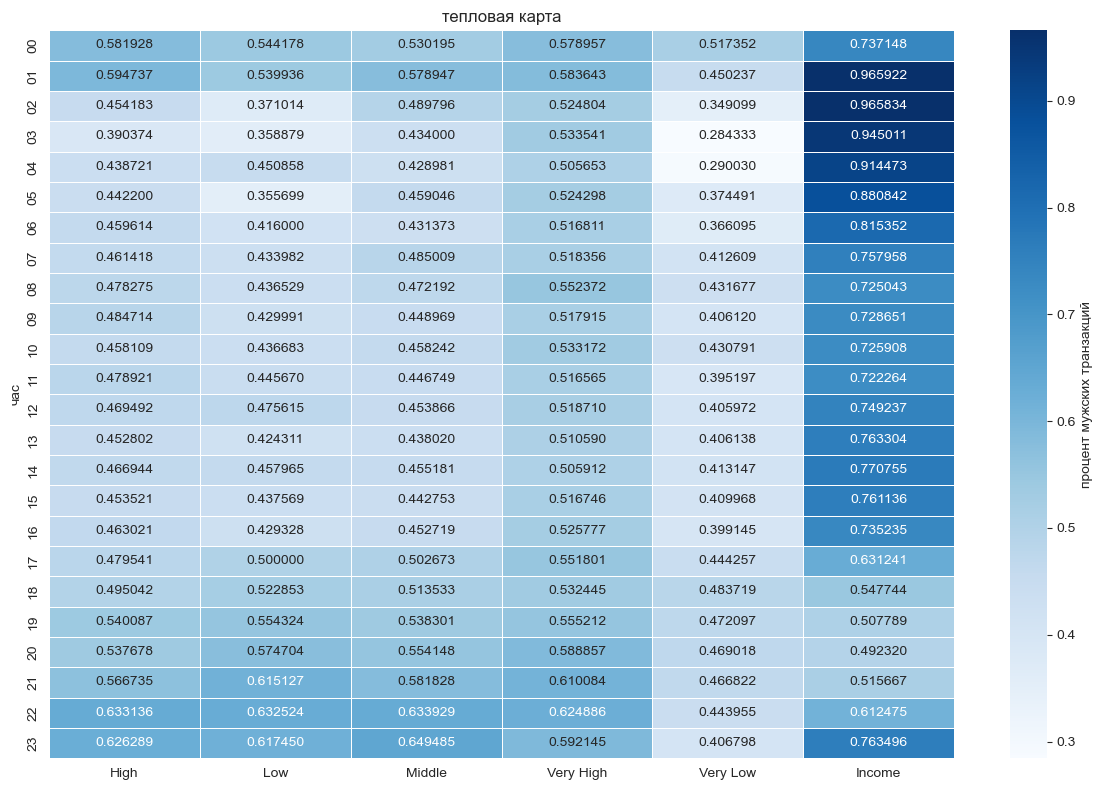

In [149]:
def plot_pivot_table(pivot_table):
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, 
                annot=True,
                fmt='f',
                cmap='Blues',
                linewidths=0.5,
                cbar_kws={'label': 'процент мужских транзакций'})
    
    plt.title('тепловая карта')
    plt.xlabel('')
    plt.ylabel('час')
    plt.tight_layout()
    plt.show()

plot_pivot_table(pivot)

### Вопросы:
 1) Ночные поступления денег (01-05 часов) в более чем 85% случаев являются мужскими.
 2) Посмотрев на долю мужчин в поступлениях средств (Income), можно сделать вывод, что количество поступлений средств женщинам в целом больше, чем мужчинам.
 3) Самые низкие траты в 3 часа ночи осуществляются в более 70% случаев женщинами.
 4) Существуют особые часы в мелких тратах, когда женщины тратят намного больше мужчин (>80%)
 5) Посмотрев на долю мужчин в максимальных тратах средств (Very High), можно сделать вывод, что количество высоких трат в каждый возможный час мужчин больше, чем у женщин.

ответы на вопросы:
1. Да
2. Нет
3. Да
4. Нет
5. Да

### Task 8.
1. Измените тип поля tr_day на int.
2. Выберите из transactions все MCC коды, которые встретились в выборке более чем 60000 раз.
3. Сгруппируйте отфильтрованный датафрейм по дню и MCC-коду, получая средние значения суммы amount.  
4. Далее отрисуйте зависимость средних сумм (может пригодится метод unstack()) по каждому из MCC-кодов по дням.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) 2 из полученных MCC-кодов связаны с финансовыми институтами
     2) 2 MCC кода, связанные со снятием наличности имеют в целом разные знаки (в одном случае почти везде - траты, в другом - пополнения)
     3) Бакалейные магазины обладают максимальными средними тратами среди выбранных MCC-кодов
     4) Денежные переводы имеют как минимум 3 явных минимума средних
     5) Категория "Звонки с использованием телефонов, считывающих магнитную ленту" имеет визуально очень большую дисперсию. 

In [45]:
df['tr_day'] = df['tr_day'].astype(int)
mcc_counts = df['mcc_code'].value_counts().to_dict()
mcc_60 = [mcc for mcc, count in mcc_counts.items() if count > 60000]
filtered_df = df[df['mcc_code'].isin(mcc_60)]
print(f'MCC коды, которые встретились более чем 60000 раз: {mcc_60}')

grouped_df = filtered_df.groupby(['tr_day', 'mcc_code'])['amount'].mean().reset_index()
grouped_df = grouped_df.rename(columns={'amount': 'avg_amount'})
print(grouped_df)


MCC коды, которые встретились более чем 60000 раз: [6011, 6010, 5411, 4814, 4829]
      tr_day  mcc_code     avg_amount
0          0      4814   -5631.316489
1          0      4829 -214754.866266
2          0      5411  -15462.567344
3          0      6010   90390.672987
4          0      6011  -55388.115175
...      ...       ...            ...
2280     456      4814   -5945.182500
2281     456      4829 -274049.766409
2282     456      5411  -15411.548528
2283     456      6010  109925.614017
2284     456      6011   18406.478780

[2285 rows x 3 columns]


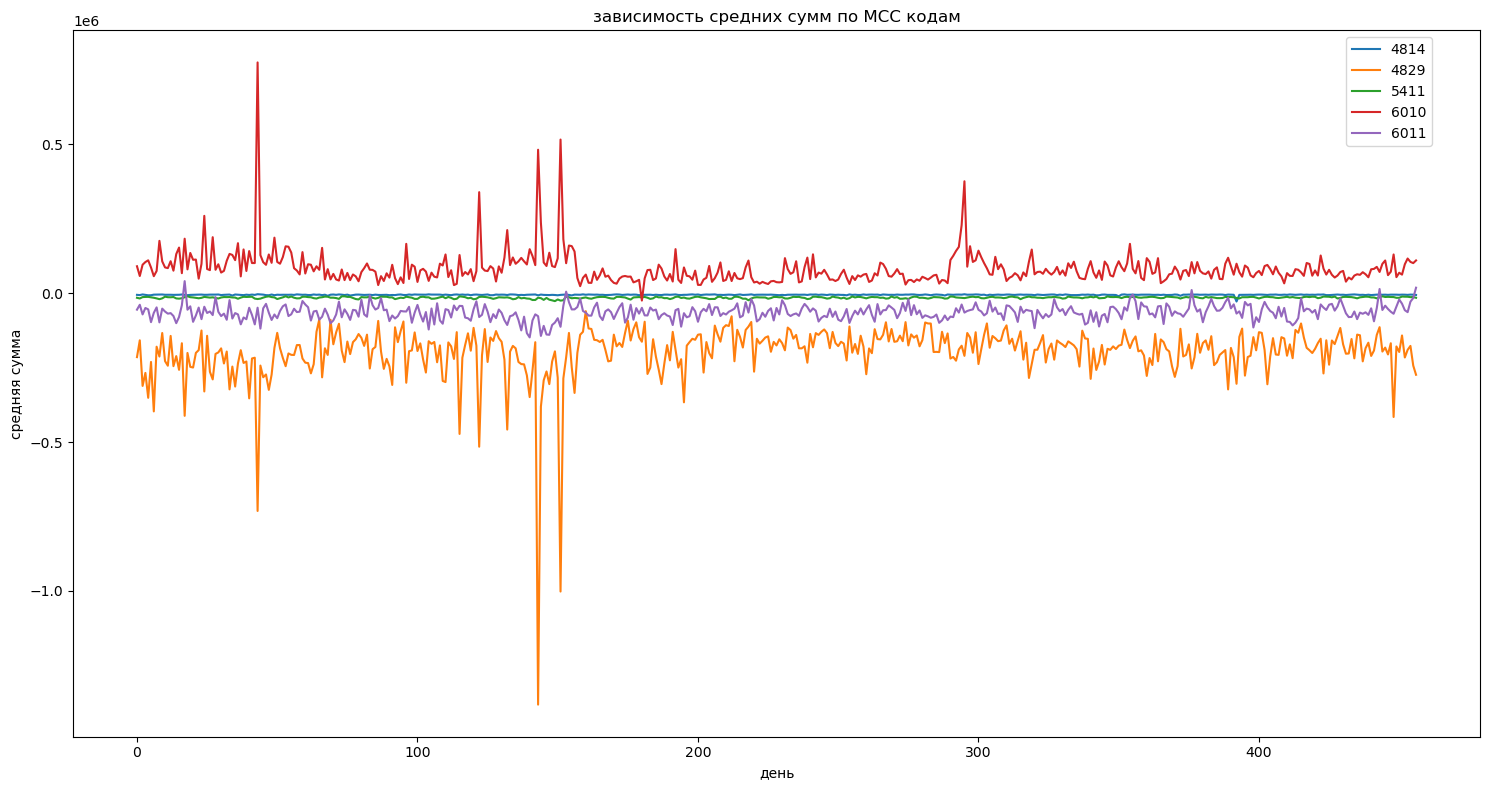

In [53]:
grouped_series = filtered_df.groupby(['tr_day', 'mcc_code'])['amount'].mean()
pivot_data = grouped_series.unstack()
plt.figure(figsize=(15, 8))
for column in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[column], linewidth=1.5, markersize=3, label=column)
plt.xlabel('день')
plt.ylabel('средняя сумма')
plt.title('зависимость средних сумм по MCC кодам')
plt.legend(bbox_to_anchor=(0.9, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

Вопросы:
 1) 2 из полученных MCC-кодов связаны с финансовыми институтами
 2) 2 MCC кода, связанные со снятием наличности имеют в целом разные знаки (в одном случае почти везде - траты, в другом - пополнения)
 3) Бакалейные магазины обладают максимальными средними тратами среди выбранных MCC-кодов
 4) Денежные переводы имеют как минимум 3 явных минимума средних
 5) Категория "Звонки с использованием телефонов, считывающих магнитную ленту" имеет визуально очень большую дисперсию.

In [123]:
filtered_df.loc[:, 'mcc_description'] = filtered_df['mcc_description'].astype(str)
finance_df = filtered_df[filtered_df['mcc_description'].str.contains('Финансовые институты', na=False)]
print(f"MCC-коды связаные с финансовыми институтами: {finance_df['mcc_code'].unique()}")

nal_df = filtered_df[filtered_df['mcc_description'].str.contains('снятие наличности')]
print(f"MCC-коды связаные со снятием наличности: {nal_df['mcc_code'].unique()}")

bak_df = filtered_df[filtered_df['mcc_description'].str.contains('Бакалейные магазины')]
print(f"MCC-коды связаные с бакалейными магазинами: {bak_df['mcc_code'].unique()}")

df_calls = filtered_df[filtered_df['mcc_description'].str.contains('Звонки с использованием телефонов, считывающих магнитную ленту')]
print(f"Звонки с использованием телефонов, считывающих магнитную ленту: {df_calls['mcc_code'].unique()}")

MCC-коды связаные с финансовыми институтами: [6011 6010]
MCC-коды связаные со снятием наличности: [6011 6010]
MCC-коды связаные с бакалейными магазинами: [5411]
Звонки с использованием телефонов, считывающих магнитную ленту: [4814]


ответы на вопросы:
1. Да
2. Да
3. Нет
4. Да
5. Нет

### Task 9:
Считайте данные из файла 'winemag-data-130k-v2.csv'.

а) Постройте точечный график (Scatter plot), по оси х отложите points, а по y - price.

In [158]:
df = pd.read_csv('winemag-data-130k-v2.csv', on_bad_lines='skip', sep=';')
#df['price'] = pd.to_numeric(df['price'], errors='coerce')
#df['points'] = pd.to_numeric(df['points'], errors='coerce')
#df_clean = df.dropna(subset=['price', 'points'])
print(df_clean.tail(5))

                                              Unnamed: 0  \
65080  65381,Spain,"Burnt, stalky, toasted aromas dom...   
65108                                              65413   
65114  65419,US,"This seems to be a little on the wat...   
65117                                              65422   
65179  65484,US,"The fruit comes from the Seven Hills...   

                                                 country  \
65080        with fully oaked flavors of medicinal berry   
65108                                             Israel   
65114   nor the fruit concentration that would elevat...   
65117                                              Italy   
65179                             the fruit more precise   

                                             description  \
65080                      hickory and barbecued meat.""   
65108  This wine is dominated by sweet oak aromas of ...   
65114   with very light citrus and apple fruit flavor...   
65117  MorAle is an impressive value w

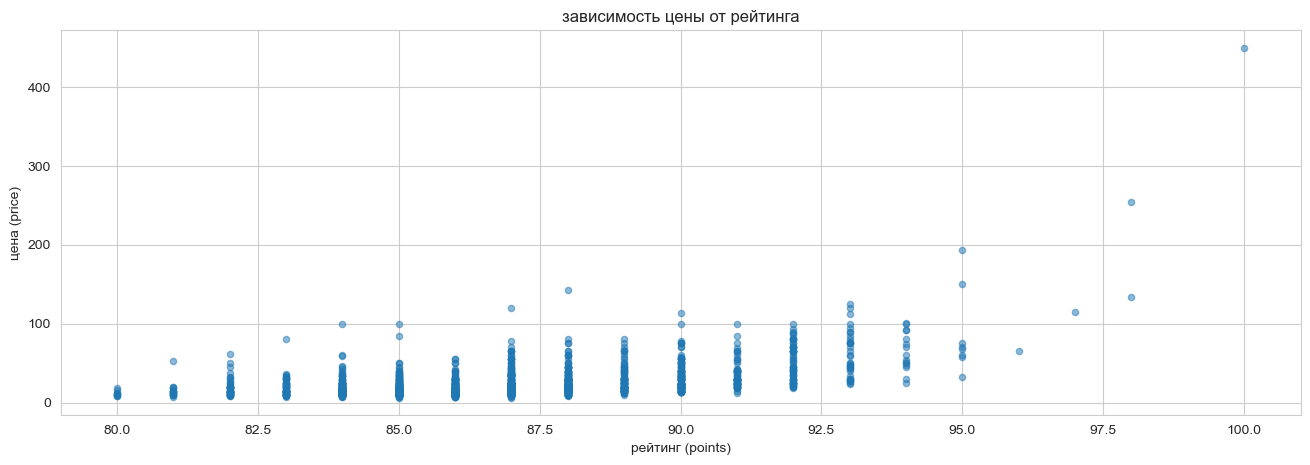

In [90]:
df_clean.plot.scatter(x='points', y='price', alpha=0.5, figsize=(16, 5))
plt.title('зависимость цены от рейтинга')
plt.xlabel('рейтинг (points)')
plt.ylabel('цена (price)')
plt.show()

б) Постройте график Barplot количества вин по странам.

C:\Users\ekete\AppData\Local\Temp\ipykernel_4304\2643340445.py:9: UserWarning: Glyph 152 (\x98) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ekete\AppData\Local\Temp\ipykernel_4304\2643340445.py:9: UserWarning: Glyph 127 () missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ekete\AppData\Local\Temp\ipykernel_4304\2643340445.py:9: UserWarning: Glyph 26 () missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ekete\AppData\Local\Temp\ipykernel_4304\2643340445.py:9: UserWarning: Glyph 25 () missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ekete\AppData\Local\Temp\ipykernel_4304\2643340445.py:9: UserWarning: Glyph 12 () missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ekete\AppData\Local\Temp\ipykernel_4304\2643340445.py:9: UserWarning: Glyph 2 () missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ekete\AppData\Local\Temp\ipykernel_4304\2643340445.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made lar

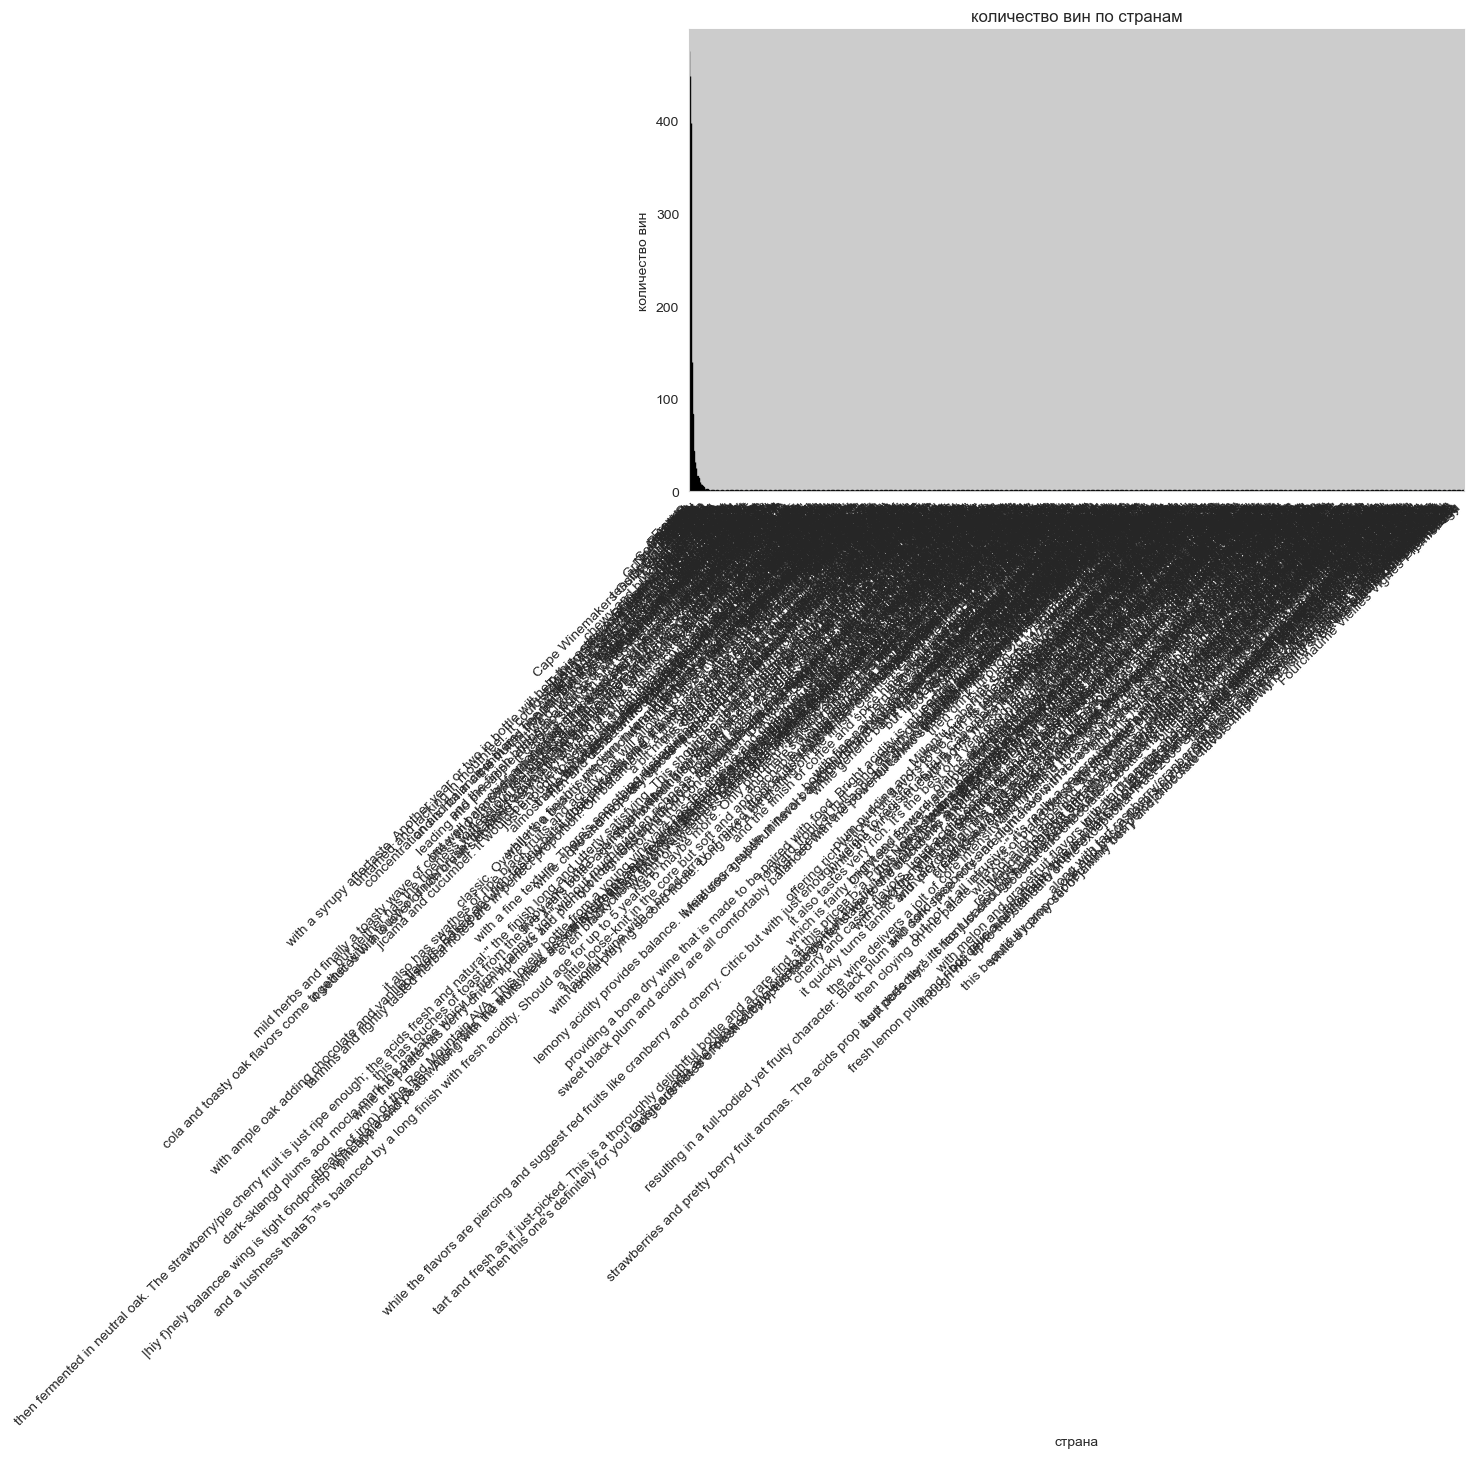

In [168]:
#df_wines_country = df.dropna(subset=['country'])
plt.figure(figsize=(10, 6))
country_wines = df_country['country'].value_counts()
country_wines.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('количество вин по странам')
plt.xlabel('страна')
plt.ylabel('количество вин')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()